# LING 498 Hackathon - Zipf in words (wordforms)
**Question: Do word tokens show a Zipf-like rank–frequency curve in a corpus slice?**

In other words, if we count every word in a corpus, do a few words occur extremely often while most words occur rarely?

In [ ]:
import re
from nltk.corpus import brown
from nltk import FreqDist

# if NLTK Brown corpus isn't already downloaded in runtime, uncomment:
# nltk.download('brown')

In [77]:
# Helpter functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Types: {len(ranked)} | Tokens: {sum(c for _,c in ranked)}")
    print("Top items:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Load category of choice
tokens = brown.words(categories='news')
print(f"Loaded {len(tokens)} tokens from Brown corpus category 'news'")

Loaded 100554 tokens from Brown corpus category 'news'


In [79]:
# Filter tokens that are only punctuation &Lowercase and remove punctuation
words = [
    token.lower()
    for token in tokens
    if not re.fullmatch(r"\W+", token) 
]
print(words[:10])

['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of']



=== News ===
Types: 13099 | Tokens: 88592
Top items:
 1. the                                      6386
 2. of                                       2861
 3. and                                      2186
 4. to                                       2144
 5. a                                        2130
 6. in                                       2020
 7. for                                      969
 8. that                                     829
 9. is                                       733
10. was                                      717
11. on                                       691
12. he                                       642
13. at                                       636
14. with                                     567
15. be                                       526

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 1.116
 f1/(3*f3) = 0.974
 f1/(4*f4) = 0.745
 f1/(5*f5) = 0.6


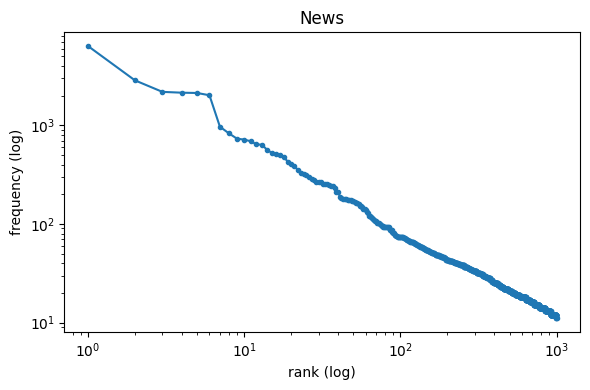

In [83]:
ranked = zipf_quick_report(words, title="News")
zipf_plot(ranked, title="News")

# Additional ranking to see other patterns
# for i, (word, count) in enumerate(ranked[15:40], start=16):
#     print(f"{i:>2}. {word:<15} {count}")